In [39]:
import numpy as np
import matplotlib.pyplot as plt

import codecs
import re
import os.path


from collections import Counter
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import nltk
# nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, auc, \
    roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from wordcloud import WordCloud

import sys
import os
sys.path.append(os.path.abspath("../../../src"))

from rital.preprocessing import (
    load_presidents,
    load_movies,
    preprocess,
    vectorize,
    plot_word_cloud,
    plot_frequencies,
    compute_odds_ratio
)

DATA_DIR = "../../../data"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Données reconnaissance du locuteur (Chirac/Mitterrand)

1 is Chirac, 0 is Mitterrand.

In [23]:
texts_pres, labels_pres = load_presidents(DATA_DIR+"/presidents/presidents.utf8")

In [24]:
assert len(texts_pres) == len(labels_pres)
print(f"Corpus with {len(texts_pres)} documents")
print( f"Label {labels_pres[0]} :\n {texts_pres[0][:100]}")
print( f"Label {labels_pres[-1]} :\n {texts_pres[-1][:100]}")

Corpus with 57413 documents
Label 1 :
  Quand je dis chers amis, il ne s'agit pas là d'une formule diplomatique, mais de l'expression de ce
Label 1 :
  Je compte sur vous.



# Données classification de sentiments (films)

1 is positive, 0 is negative.

In [25]:
texts_mov, labels_mov = load_movies(DATA_DIR+"/movies/")

In [26]:
assert len(texts_mov) == len(labels_mov)
print(f"Corpus with {len(texts_mov)} documents")
print( f"Label {labels_mov[0]} :\n {texts_mov[0][:100]}")
print( f"Label {labels_mov[-1]} :\n {texts_mov[-1][:100]}")

Corpus with 2000 documents
Label 0 :
 bad . bad . 
bad . 
that one word seems to pretty much sums up beyond the valley of the dolls . 
if 
Label 1 :
 capsule : the director of cure brings a weird and very complex concept to the screen . 
one viewing 


# A) Transformation paramétrique du texte (pre-traitements)

Vous devez tester, par exemple, les cas suivants:
- transformation en minuscule ou pas
- suppression de la ponctuation
- transformation des mots entièrement en majuscule en marqueurs spécifiques
- suppression des chiffres ou pas
- conservation d'une partie du texte seulement (seulement la première ligne = titre, seulement la dernière ligne = résumé, ...)
- stemming
- ...


Vérifier systématiquement sur un exemple ou deux le bon fonctionnement des méthodes sur deux documents (au moins un de chaque classe).

In [27]:
X_mov, vocab_mov = vectorize(texts_mov, 
                             TfidfVectorizer, # CountVectorizer
                             preprocess, 
                             language= "english",
                             ngram_range=(1,1),
                             remove_stopwords=True,
                             stem=True)

X_pres, vocab_pres = vectorize(texts_pres, 
                             TfidfVectorizer, # CountVectorizer
                             preprocess, 
                             language= "french",
                             ngram_range=(1,1),
                             remove_stopwords=True,
                             stem=True)

# B) Extraction du vocabulaire (BoW)

- **Exploration préliminaire des jeux de données**
    - Quelle est la taille d'origine du vocabulaire?
    - Que reste-t-il si on ne garde que les 100 mots les plus fréquents? [word cloud]
    - Quels sont les 100 mots dont la fréquence documentaire est la plus grande? [word cloud]
    - Quels sont les 100 mots les plus discriminants au sens de odds ratio? [word cloud]
    - Quelle est la distribution d'apparition des mots (Zipf)
    - Quels sont les 100 bigrammes/trigrammes les plus fréquents?

- **Variantes de BoW**
    - TF-IDF
    - Réduire la taille du vocabulaire (min_df, max_df, max_features)
    - BoW binaire
    - Bi-grams, tri-grams
    - **Quelles performances attendre ? Quels sont les avantages et les inconvénients des ces variantes?**

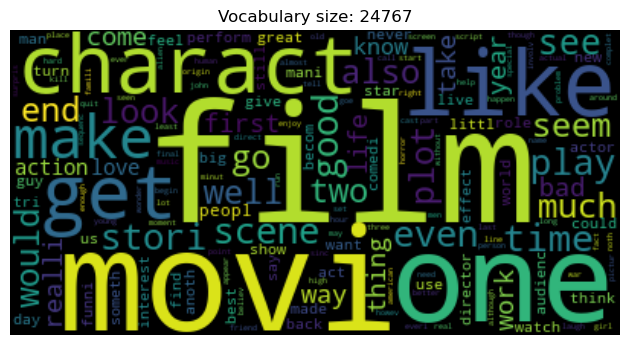

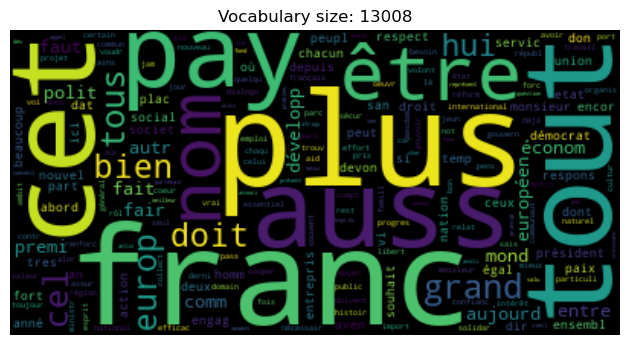

In [28]:
plot_word_cloud(vocab_mov, X_mov.sum(0).A1, title=f"Vocabulary size: {len(vocab_mov)}")
plot_word_cloud(vocab_pres, X_pres.sum(0).A1, title=f"Vocabulary size: {len(vocab_pres)}")

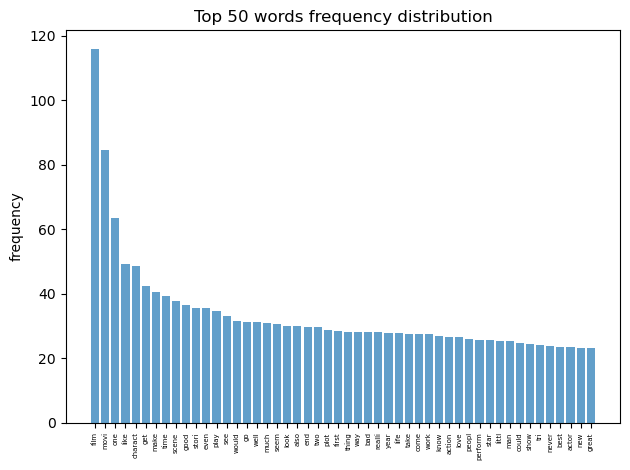

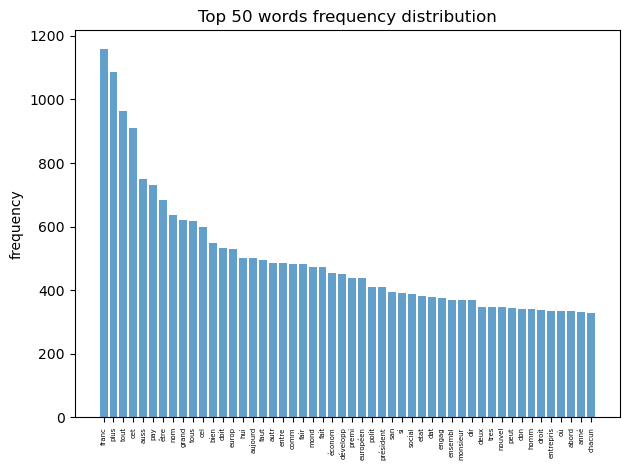

In [29]:
plot_frequencies(vocab_mov, X_mov.sum(0).A1, top_k=50)
plot_frequencies(vocab_pres, X_pres.sum(0).A1, top_k=50)

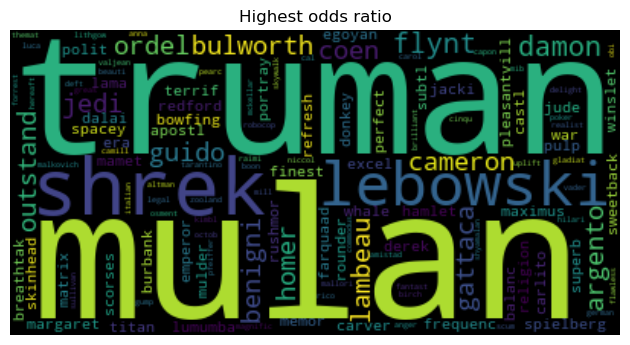

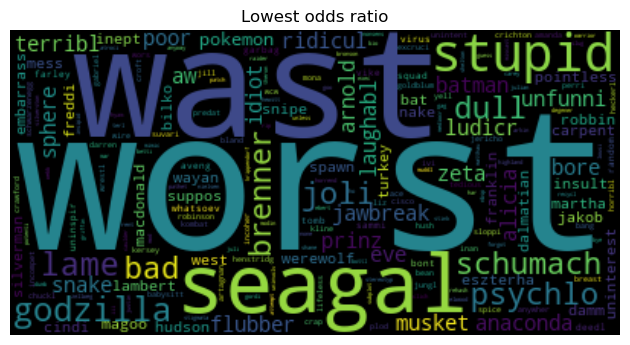

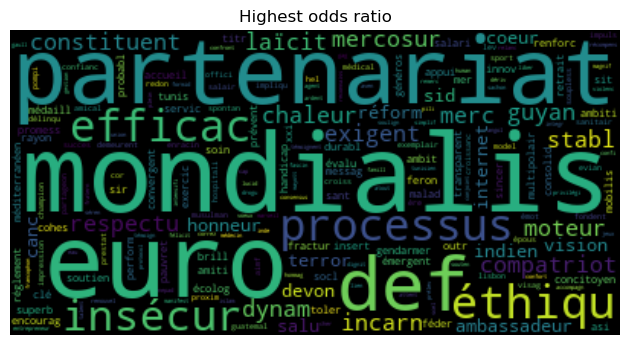

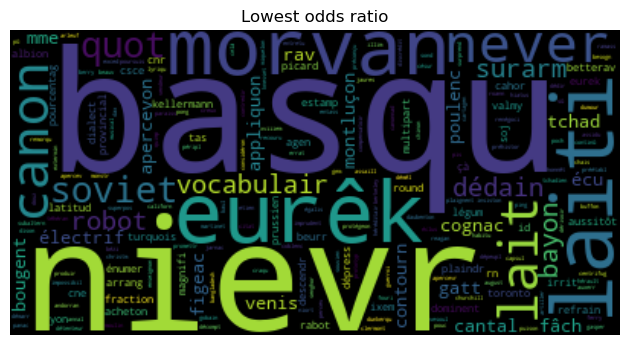

In [30]:
odds_ratio_mov = compute_odds_ratio(X_mov, labels_mov)
odds_ratio_pres = compute_odds_ratio(X_pres, labels_pres)
plot_word_cloud(vocab_mov,odds_ratio_mov, title=f"Highest odds ratio")
plot_word_cloud(vocab_mov, 1/odds_ratio_mov, title=f"Lowest odds ratio")

plot_word_cloud(vocab_pres,odds_ratio_pres, title=f"Highest odds ratio")
plot_word_cloud(vocab_pres, 1/odds_ratio_pres, title=f"Lowest odds ratio")

# C) Modèles de Machine Learning

## 1) Métriques d'évaluation

Il faudra utiliser des métriques d'évaluation pertinentes suivant la tâche et l'équilibrage des données :
- Accuracy
- Courbe ROC, AUC, F1-score

## 2) Variantes sur les stratégies d'entraînement

- **Sur-apprentissage**. Les techniques sur lesquelles nous travaillons étant sujettes au sur-apprentissage: trouver le paramètre de régularisation dans la documentation et optimiser ce paramètre au sens de la métrique qui vous semble la plus appropriée (cf question précédente).


- **Equilibrage des données**. Un problème reconnu comme dur dans la communauté est celui de l'équilibrage des classes (*balance* en anglais). Que faire si les données sont à 80, 90 ou 99% dans une des classes?
Le problème est dur mais fréquent; les solutions sont multiples mais on peut isoler 3 grandes familles de solution.

   1. Ré-équilibrer le jeu de données: supprimer des données dans la classe majoritaire et/ou sur-échantilloner la classe minoritaire.
      $\Rightarrow$ A vous de jouer pour cette technique
   1. Changer la formulation de la fonction de coût pour pénaliser plus les erreurs dans la classe minoritaire:
   soit une fonction $\Delta$ mesurant les écarts entre $f(x_i)$ et $y_i$
      $$C = \sum_i  \alpha_i \Delta(f(x_i),y_i), \qquad \alpha_i = \left\{
      \begin{array}{ll}
      1 & \text{si } y_i \in \text{classe majoritaire}\\
      B>1 & \text{si } y_i \in \text{classe minoritaire}\\
      \end{array} \right.$$
      $\Rightarrow$ Les SVM et d'autres approches sklearn possèdent des arguments pour régler $B$ ou $1/B$... Ces arguments sont utiles mais pas toujours suffisant.
   1. Courbe ROC et modification du biais. Une fois la fonction $\hat y = f(x)$ apprise, il est possible de la *bidouiller* a posteriori: si toutes les prédictions $\hat y$ sont dans une classe, on va introduire $b$ dans $\hat y = f(x) + b$ et le faire varier jusqu'à ce qu'un des points change de classe. On peut ensuite aller de plus en plus loin.
   Le calcul de l'ensemble des scores associés à cette approche mène directement à la courbe ROC.

**Note:** certains classifieurs sont intrinsèquement plus résistante au problème d'équilibrage, c'est par exemple le cas des techniques de gradient boosting que vous verrez l'an prochain.

In [31]:
print(np.array(labels_mov).sum() / np.array(labels_mov).shape[0])
print(np.array(labels_pres).sum() / np.array(labels_pres).shape[0])

0.5
0.8689669587027329


F1-score: 0.8312958435207825


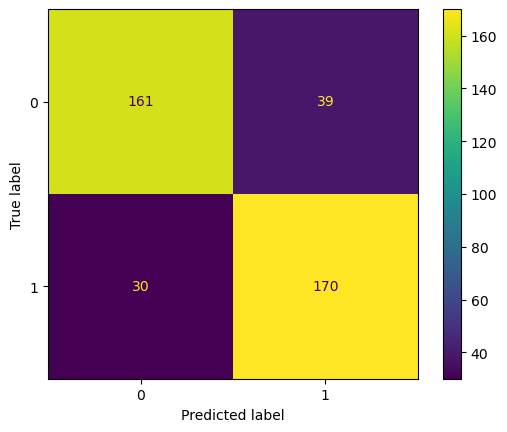

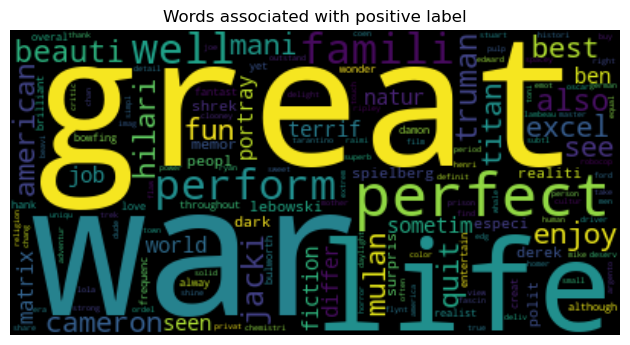

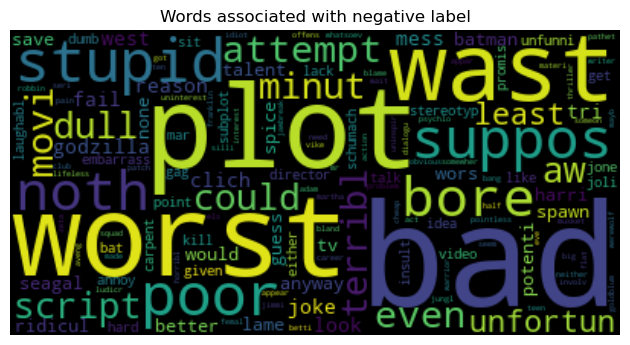

In [32]:
X = X_mov
y = labels_mov
vocab = vocab_mov

X_train, X_test, y_train, y_test  = \
train_test_split(X, y,
                test_size=0.2, 
                random_state=42, 
                shuffle=True, 
                stratify=y)

svm = LinearSVC(C=0.1, class_weight="balanced")

# TODO: do other models with regularization and class balance

svm.fit(X_train, y_train)
y_hat = svm.predict(X_test)

print(f"F1-score: {f1_score(y_test, y_hat)}")
ConfusionMatrixDisplay.from_predictions(y_test, y_hat)
plt.show()

plot_word_cloud(vocab, svm.coef_[0], title="Words associated with positive label")
plot_word_cloud(vocab, -svm.coef_[0], title="Words associated with negative label")

F1-score: 0.8864917082595395


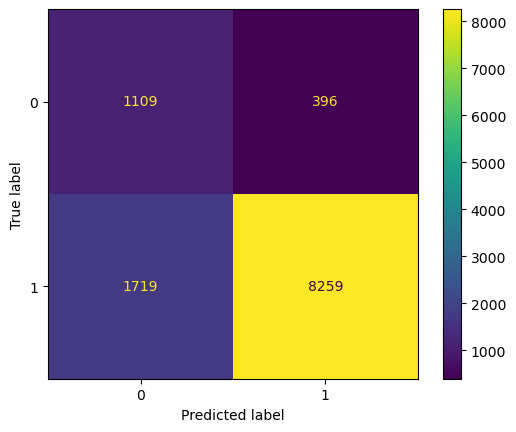

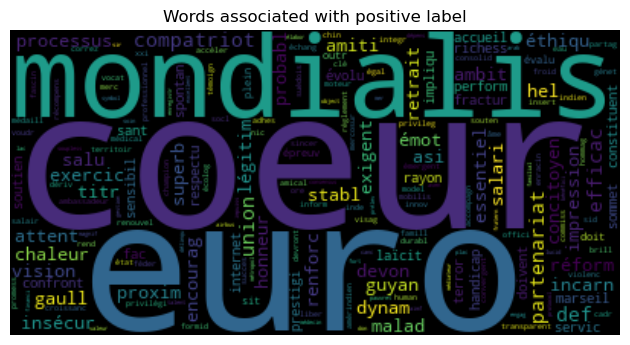

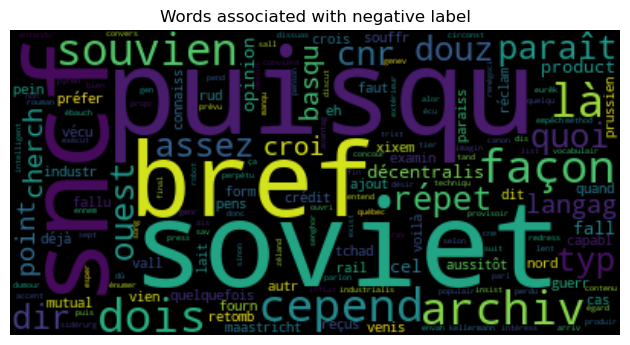

In [33]:
X = X_pres
y = labels_pres
vocab = vocab_pres

X_train, X_test, y_train, y_test  = \
train_test_split(X, y,
                test_size=0.2, 
                random_state=42, 
                shuffle=True, 
                stratify=y)

svm = LinearSVC(C=0.1, class_weight="balanced")

# TODO: do other models with regularization and class balance

svm.fit(X_train, y_train)
y_hat = svm.predict(X_test)

print(f"F1-score: {f1_score(y_test, y_hat)}")
ConfusionMatrixDisplay.from_predictions(y_test, y_hat)
plt.show()

plot_word_cloud(vocab, svm.coef_[0], title="Words associated with positive label")
plot_word_cloud(vocab, -svm.coef_[0], title="Words associated with negative label")



## 3) Post-processing sur les données Président

Pour la tâche de reconnaissance de locuteur, des phrases successives sont souvent associés à un même locuteur. Voir par exemples les 100 premiers labels de la base d'apprentissage.

In [34]:
X = X_pres
y = labels_pres
vocab = vocab_pres

# Keep track of indices to restore the time order
X_train, X_test, y_train, y_test, indices_train, indices_test  = \
train_test_split(X, y, np.arange(X.shape[0]),
                test_size=0.2, 
                random_state=42, 
                shuffle=True, 
                stratify=y)

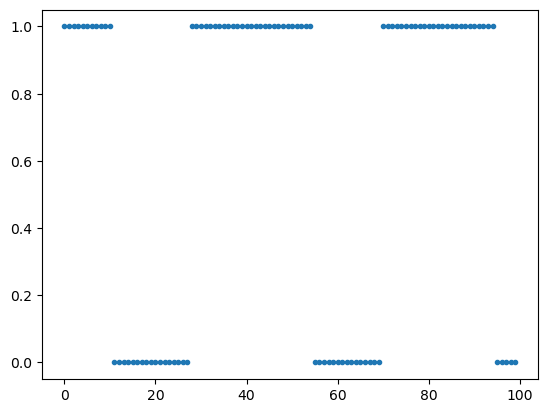

In [35]:
plt.plot(range(100),y[0:100], ".")
plt.show()

**Une méthode de post-traitement pour améliorer les résultats consistent à lisser les résultats de la prédictions d'une phrases par les prédictions voisines, en utilisant par exemple une convolution par une filtre Gaussien. Compléter la fonction ci-dessous et tester l'impact de ce lissage sur les performances.**

In [36]:
def gaussian_smoothing(pred, size):
    # TODO:
    # LISSAGE par un filtre Gaussien de taille size - vous pouvez utiliser np.convolve
    assert size % 2 == 1, "size must be odd"
    sigma = size/6
    k = size // 2
    x = np.arange(-k,k+1)
    kernel = np.exp(-0.5 * (x/sigma)**2)
    kernel /= np.sum(kernel)
    pred_padded = np.pad(pred, pad_width=k, mode="edge")
    return np.convolve(pred_padded, kernel, mode="valid")

In [37]:
indices_test_sorted, y_test_sorted = map(np.array,zip(*sorted(zip(indices_test, y_test), key=lambda x: x[0])))
indices_test_sorted, y_hat_sorted = map(np.array,zip(*sorted(zip(indices_test, y_hat), key=lambda x: x[0])))
y_hat_smoothed = np.round(gaussian_smoothing(y_hat_sorted, size=5))

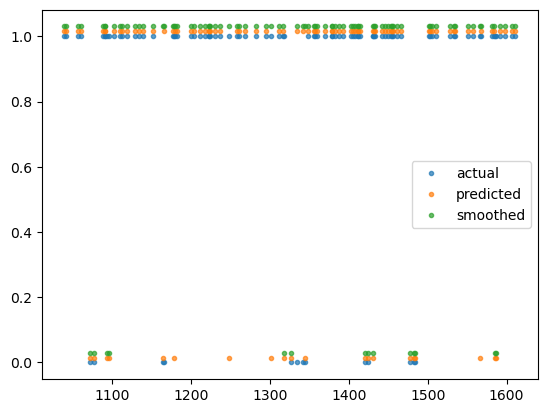

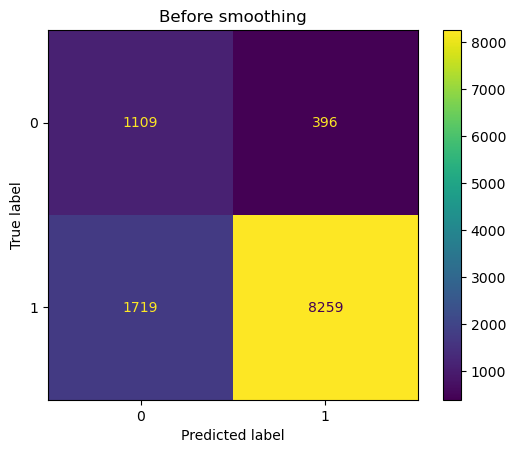

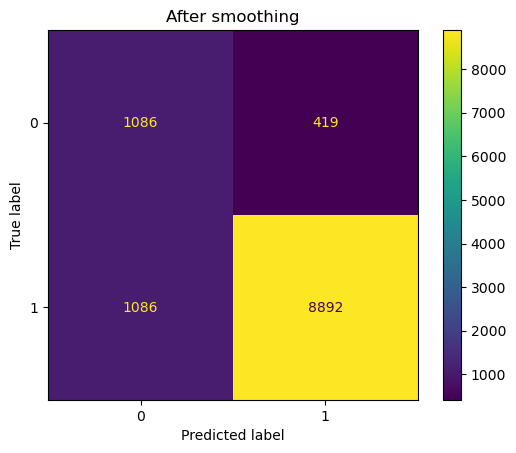

In [38]:
slc = slice(200, 300)
plt.plot(indices_test_sorted[slc],y_test_sorted[slc],".", label="actual", alpha=0.7)
plt.plot(indices_test_sorted[slc],y_hat_sorted[slc]+0.015,".", label="predicted", alpha=0.7)
plt.plot(indices_test_sorted[slc],y_hat_smoothed[slc]+0.03,".", label="smoothed", alpha=0.7)
plt.legend()
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test_sorted, y_hat_sorted)
plt.title("Before smoothing")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test_sorted, y_hat_smoothed)
plt.title("After smoothing")
plt.show()


## 4) Estimer les performances de généralisation d'une méthodes
**Ce sera l'enjeu principal du projet : vous disposez d'un ensemble de données, et vous évaluerez les performances sur un ensemble de test auquel vous n'avez pas accès. Il faut donc être capable d'estimer les performances de généralisation du modèles à partir des données d'entraînement.**


Avant de lancer de grandes expériences, il faut se construire une base de travail solide en étudiant les questions suivantes:

- Combien de temps ça prend d'apprendre un classifieur NB/SVM/RegLog sur ces données en fonction de la taille du vocabulaire?
- La validation croisée est-elle nécessaire? Est ce qu'on obtient les mêmes résultats avec un simple *split*?
- La validation croisée est-elle stable? A partir de combien de fold (travailler avec différentes graines aléatoires et faire des statistiques basiques)?